In [177]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
import operator

In [178]:
load_dotenv()


True

In [198]:
generator_llm=ChatOpenAI(model="gpt-4o-mini")
Evalutor_llm=ChatOpenAI(model="gpt-5.6-sol")
optimizer_llm=ChatOpenAI(model="gpt-5.6-luna")

In [180]:
from pydantic import BaseModel, Field

class PostEval(BaseModel):
    evaluation:Literal["approved","needs_improvement"] = Field("Final evaluation result")
    feedback: str = Field(description="constructive feedback for post")


In [181]:
structured_eval_llm=Evalutor_llm.with_structured_output(PostEval)

In [182]:
class PostState(TypedDict):
    topic: str
    post: str
    evaluation: Literal["approved","needs_improvement"]
    feedback: str
    iteration: int
    max_itr: int
    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [ ]:
def generate_post(state:PostState):
    message = [
        SystemMessage(
            content="""Write a LinkedIn post based on the learnings from an agentic AI course. Make it sound human, authentic, witty, and relatable. Use observational humor, irony, cultural references, or workplace examples where appropriate. Avoid generic corporate language and keep the post under 250 words. Use day to day english. Write in no more than 250 words."""
        ),
        HumanMessage(
            content=f"Create a LinkedIn post about this topic: {state['topic']}"
        ),
    ]

    post = generator_llm.invoke(message).content
    return {"post": post,"post_history":[post] }

In [202]:
def evaluate_post(state:PostState):
    message=[
                SystemMessage(content=f"""You are an expert evaluator and a ruthless crtic of LinkedIn posts. Assess each post objectively and thoughtfully for authenticity, human-like voice, wit, engagement, originality, relevance, professionalism,adherence to the provided instructions and use of day to day english.

                            Carefully examine the posts wording, tone, structure, humor, cultural references, examples, and key takeaway. Determine whether it sounds personal and relatable rather than generic, formulaic, or AI-generated. Consider whether humor or irony strengthens the post without undermining professionalism, whether the connection to agentic AI or the course is clear, and whether the post avoids clichés, vague motivational language, and unsupported claims.

                            Your feedback must include both specific strengths and weaknesses. Reference concrete elements from the post wherever possible. Approve the post only if it meets the criteria sufficiently as written; otherwise, mark it as needing improvement. Do not rewrite the post or provide feedback outside the required format.

                            """),
    
                HumanMessage(content= f"""
                                  Evaluate the following LinkedIn post using the criteria in the system message:

                                    LinkedIn post:

                                    post:"{state['post']}

                                    Relevant instructions or requirements for the post, if any.

                                    Return only:

                                    evaluation: "approve" or "needs_improvement"
                                    feedback: One well-written paragraph explaining the posts specific strengths and weaknesses
                      """ )]

    response=structured_eval_llm.invoke(message)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, "feedback_history":[response.feedback]}

In [194]:
def optimize_post(state:PostState):

    message= [
        SystemMessage(content="you punch up posts for virality, humor and quality of information based on given feeedback."),
        HumanMessage(content=f"""
Improve the post based on below feedback :\n
"{state['feedback']}"

original post: \n
"{state['post']}"

rewrite it as a short, viral worthy post. Avoid Q&A style and stay under 250 words.

""")
    ]

    response=optimizer_llm.invoke(message).content

    iteration= state['iteration'] + 1
    

    return {'post':response, 'iteration':iteration, "post_history":[response]}

In [186]:
def route_eval(state:PostState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_itr']:
        return 'approved'
    return 'needs_improvement'

In [195]:
graph=StateGraph(PostState)

graph.add_node("generate_post",generate_post)
graph.add_node("evaluate_post",evaluate_post)
graph.add_node("optimize_post",optimize_post)

graph.add_edge(START,'generate_post') 
graph.add_edge('generate_post','evaluate_post')
graph.add_conditional_edges('evaluate_post', route_eval, {'approved':END, 'needs_improvement':'optimize_post'})
graph.add_edge('optimize_post','evaluate_post')

workflow=graph.compile()

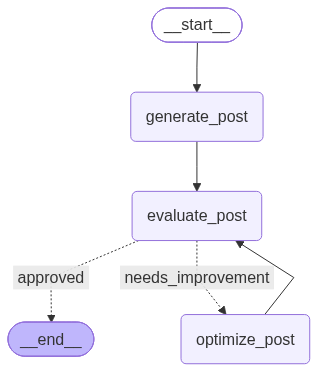

In [188]:
workflow

In [203]:
initial_state = {
    "topic": "Gen AI vs Agentic AI vs AI Agents",
    "iteration": 1,
    "max_itr": 5,
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'Gen AI vs Agentic AI vs AI Agents', 'post': '🚀 One idea from my recent AI course finally clicked:\n\nThese aren’t three separate “flavors” of AI. They describe different capabilities—and they can overlap.\n\n- **Generative AI** creates content: a draft itinerary, email, image, or code.\n- **Agentic AI** refers to goal-directed behavior: it can interpret context, break a goal into steps, weigh options, and adapt as conditions change.\n- An **AI agent** is the system putting that behavior into practice—using tools, taking actions, checking results, and trying again within its permissions.\n\nA simple example:\n\n**GenAI:** “Here’s a three-day Tokyo itinerary.”  \n**Agentic AI:** “Given your budget, dietary needs, and rainy forecast, I’ll revise the plan.”  \n**AI agent:** Searches live schedules, books the restaurant, updates your calendar, and alerts you when the train is delayed.\n\nThe key distinction: generating an answer isn’t the same as pursuing a goal—and planning isn’

In [204]:
final_state


{'topic': 'Gen AI vs Agentic AI vs AI Agents',
 'post': '🚀 One idea from my recent AI course finally clicked:\n\nThese aren’t three separate “flavors” of AI. They describe different capabilities—and they can overlap.\n\n- **Generative AI** creates content: a draft itinerary, email, image, or code.\n- **Agentic AI** refers to goal-directed behavior: it can interpret context, break a goal into steps, weigh options, and adapt as conditions change.\n- An **AI agent** is the system putting that behavior into practice—using tools, taking actions, checking results, and trying again within its permissions.\n\nA simple example:\n\n**GenAI:** “Here’s a three-day Tokyo itinerary.”  \n**Agentic AI:** “Given your budget, dietary needs, and rainy forecast, I’ll revise the plan.”  \n**AI agent:** Searches live schedules, books the restaurant, updates your calendar, and alerts you when the train is delayed.\n\nThe key distinction: generating an answer isn’t the same as pursuing a goal—and planning isn

In [191]:
intermediate_state={
    "topic": "Gen AI vs Agentic AI vs AI Agents",
    "post":"Gen AI writes the email.\n\nAn AI agent can research the prospect, update the CRM, book the meeting—and, slightly terrifyingly, click **“send.”**\n\n“Agentic AI” generally describes systems designed to pursue goals across multiple steps with some autonomy.\n\nBut here’s an important caveat I learned from a recent course: these terms aren’t standardized. Some people use **AI agents** and **agentic AI** almost interchangeably.\n\nSo treat this as a useful mental model, not a universal taxonomy:\n\n- **Gen AI** creates  \n- **AI agents** take actions  \n- **Agentic systems** plan, adapt, and work toward goals  \n\nMy biggest takeaway? **Autonomy isn’t a switch. It’s a dial.**\n\nAn AI system might:\n\n1. Recommend the next step  \n2. Act only after approval  \n3. Operate independently until it hits a boundary  \n\nEvery turn of that dial requires stronger permissions, monitoring, and fallbacks.\n\nThe real question isn’t, “Is this agentic?”\n\nIt’s: **What can it do, what can go wrong, and who stops it from offering a 90% discount?**\n\nThe future isn’t just AI that talks.\n\nIt’s AI that gets work done—without burning down the workflow.",
    "feedback": "Rewrite the post in more casual tone.",
    "iteration": 2,
    "max_itr": 5,

}

workflow.invoke(intermediate_state)

{'topic': 'Gen AI vs Agentic AI vs AI Agents',
 'post': '🌟 Welcome to the fascinating realm of AI, where creativity meets innovation! Picture Generative AI as your creative companion, effortlessly weaving together everything from inspiring poems to innovative vacation plans. It’s like having a personal storyteller, albeit with the occasional plot twist! 📖✨\n\nNow, let’s turn our attention to Agentic AI—your decision-making partner that’s more than just a reminder tool. This tech marvel can strategize your travel itinerary while ensuring you avoid those dreaded “Oops, what did I book?” moments. Think of it as your smart assistant, capable of problem-solving and executing complex tasks, all while you relax with your favorite drink! ☕✈️\n\nAnd then there are AI Agents, the quiet achievers of the digital world. They’re not just behind-the-scenes nudgers; they’re your productivity allies, seamlessly managing your tasks and keeping you on track—like a discreet sidekick ready to tackle challe